Dưới đây là tài liệu và toàn bộ mã nguồn cho Stage 2: Critic Pretraining.

Ở giai đoạn này, chúng ta sẽ xây dựng và huấn luyện "Người phán xử" (Critic Head) dựa trên nền tảng (backbone) đã được Fine-tune ở Stage 1.

Tổng quan kỹ thuật Stage 2
- Kiến trúc Shared Backbone: Thay vì tải 2 mô hình PhoBERT độc lập (gây tốn gấp đôi VRAM), chúng ta sẽ thêm một lớp Tuyến tính mới (self.critic) vào chính class mô hình ở Stage 1. Lớp này nhận đầu vào là trạng thái [CLS] và xuất ra 34 giá trị (ước lượng phần thưởng cho 34 khía cạnh).

- Cơ chế Đóng băng (Freezing): Chúng ta nạp trọng số từ file best_model_sft.bin của Stage 1, sau đó đóng băng toàn bộ (cả LoRA adapter và Actor classifier). Gradient sẽ chỉ được tính toán và cập nhật cho duy nhất lớp Critic.

- Mô phỏng Môi trường (Rollout Simulation): Vì Policy (Actor) đã bị đóng băng, chúng ta cho Actor dự đoán trên tập train. Từ dự đoán (Action) và nhãn thực tế (Ground Truth), chúng ta tính toán Phần thưởng (Reward) theo đúng công thức bạn đã đề xuất. Phần thưởng này chính là nhãn mục tiêu (Target) để Critic học cách ước lượng thông qua hàm Mean Squared Error (MSE).

--> Nói cách khác, Stage 2 đóng vai trò là cầu nối giữa SFT và Reinforcemen Learning
Đọc kĩ hơn tại:
https://docs.google.com/document/d/1VQxuCL82ZDFBma33ao2qMoiGJZPhqYtH45m2wNn_sow/edit?usp=sharing

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


>> Da nap thanh cong trong so tu Stage 1.
>> Tham so can huan luyen (Chi Critic Head): 26146
Epoch 1/5 | Critic Train Loss (MSE): 0.3863 | Val Loss: 0.2910
Epoch 2/5 | Critic Train Loss (MSE): 0.3621 | Val Loss: 0.2850
Epoch 3/5 | Critic Train Loss (MSE): 0.3552 | Val Loss: 0.2820
Epoch 4/5 | Critic Train Loss (MSE): 0.3516 | Val Loss: 0.2801
Epoch 5/5 | Critic Train Loss (MSE): 0.3493 | Val Loss: 0.2795
>> Đã lưu file 'actor_critic_pretrained.bin' chuẩn bị cho Stage 3 PPO.


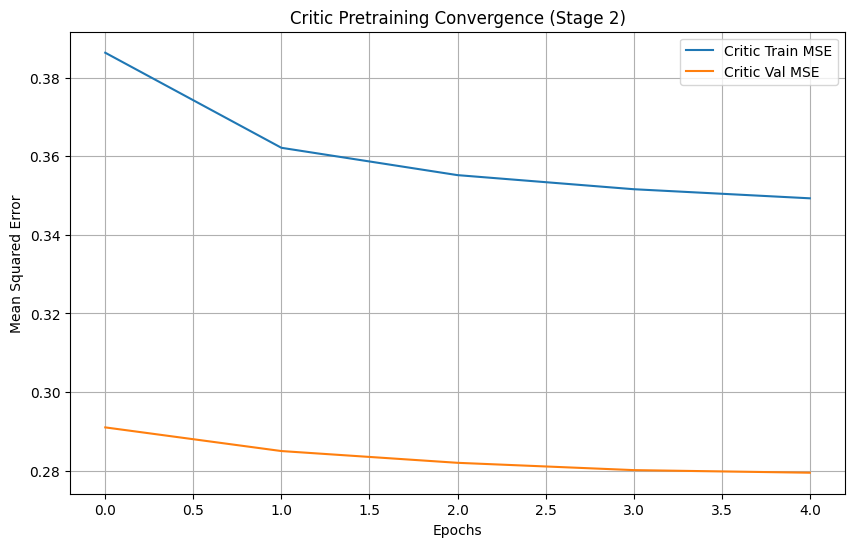

In [ ]:
!pip install --upgrade torchao
!pip install --upgrade transformers
!pip install pyvi

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
from pyvi import ViTokenizer
from peft import LoraConfig, get_peft_model

from google.colab import drive
drive.mount('/content/drive')


# Cấu hình
MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS_CRITIC = 5 # Critic hội tụ nhanh, thường chỉ cần 3-5 epochs
LEARNING_RATE_CRITIC = 1e-4 # Learning rate cho Critic thường cao hơn Actor
MODEL_NAME = "vinai/phobert-base"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAVE_PATH = '/content/drive/MyDrive/ABSA_Task2'
DATA_DIR = '/content/drive/MyDrive/task2_dataset' # Corrected path

ASPECT_COLS = [
    "FACILITIES#CLEANLINESS", "FACILITIES#COMFORT", "FACILITIES#DESIGN&FEATURES", "FACILITIES#GENERAL",
    "FACILITIES#MISCELLANEOUS", "FACILITIES#PRICES", "FACILITIES#QUALITY", "FOOD&DRINKS#MISCELLANEOUS",
    "FOOD&DRINKS#PRICES", "FOOD&DRINKS#QUALITY", "FOOD&DRINKS#STYLE&OPTIONS", "HOTEL#CLEANLINESS",
    "HOTEL#COMFORT", "HOTEL#DESIGN&FEATURES", "HOTEL#GENERAL", "HOTEL#MISCELLANEOUS", "HOTEL#PRICES",
    "HOTEL#QUALITY", "LOCATION#GENERAL", "ROOMS#CLEANLINESS", "ROOMS#COMFORT", "ROOMS#DESIGN&FEATURES",
    "ROOMS#GENERAL", "ROOMS#MISCELLANEOUS", "ROOMS#PRICES", "ROOMS#QUALITY", "ROOM_AMENITIES#CLEANLINESS",
    "ROOM_AMENITIES#COMFORT", "ROOM_AMENITIES#DESIGN&FEATURES", "ROOM_AMENITIES#GENERAL",
    "ROOM_AMENITIES#MISCELLANEOUS", "ROOM_AMENITIES#PRICES", "ROOM_AMENITIES#QUALITY", "SERVICE#GENERAL"
]

# ==========================================
# DATALOADER (Kế thừa từ Stage 1)
# ==========================================
class ABSADataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.texts = df['Review'].values
        self.labels = df[ASPECT_COLS].values

    def __len__(self):
        return len(self.df)

    def preprocess(self, text):
        return ViTokenizer.tokenize(str(text).lower())

    def __getitem__(self, index):
        text = self.preprocess(self.texts[index])
        labels = self.labels[index]

        encoding = self.tokenizer(
            text, truncation=True, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', return_attention_mask=True, return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(labels, dtype=torch.long)
        }

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_df = pd.read_csv(f"{DATA_DIR}/1-VLSP2018-SA-Hotel-train.csv")
dev_df = pd.read_csv(f"{DATA_DIR}/2-VLSP2018-SA-Hotel-dev.csv")

train_loader = DataLoader(ABSADataset(train_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(ABSADataset(dev_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE)

# ==========================================
# KIẾN TRÚC ACTOR-CRITIC (SHARED BACKBONE)
# ==========================================
class PhoBertACSA_ActorCritic(nn.Module):
    def __init__(self, n_aspects, n_polarities):
        super(PhoBertACSA_ActorCritic, self).__init__()

        phobert = AutoModel.from_pretrained(MODEL_NAME)
        lora_config = LoraConfig(
            r=8, lora_alpha=16, target_modules=["query", "value"], lora_dropout=0.1, bias="none"
        )
        self.phobert = get_peft_model(phobert, lora_config)
        self.dropout = nn.Dropout(p=0.3)

        # ACTOR HEAD (Đã train ở Stage 1)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, n_aspects * n_polarities)

        # CRITIC HEAD (Mới bổ sung cho Stage 2) - Dự đoán 1 giá trị (value) cho mỗi aspect
        self.critic = nn.Linear(self.phobert.config.hidden_size, n_aspects)

        self.n_aspects = n_aspects
        self.n_polarities = n_polarities

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)

        logits = self.classifier(pooled_output) # (batch, 34*4)
        values = self.critic(pooled_output)     # (batch, 34)

        return logits.view(-1, self.n_aspects, self.n_polarities), values

model = PhoBertACSA_ActorCritic(n_aspects=len(ASPECT_COLS), n_polarities=4).to(DEVICE)

# Nạp trọng số từ Stage 1. Sử dụng strict=False để bỏ qua việc thiếu tham số của lớp 'critic' mới
stage1_checkpoint = f"{SAVE_PATH}/best_model_sft.bin"
model.load_state_dict(torch.load(stage1_checkpoint), strict=False)
print(">> Da nap thanh cong trong so tu Stage 1.")

# ĐÓNG BĂNG (FREEZE) Actor & Backbone. CHỈ cho phép train Critic Head
for name, param in model.named_parameters():
    if 'critic' not in name:
        param.requires_grad = False
    else:
        param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f">> Tham so can huan luyen (Chi Critic Head): {trainable_params}")

# ==========================================
# HÀM TÍNH REWARD (TARGET CHO CRITIC)
# ==========================================
def compute_step_rewards(preds, labels):
    """
    Tính reward dựa trên luật đã quy định:
    Negative(2) / Neutral(3) đúng: +2.0
    Positive(1) đúng: +1.0
    None(0) đúng: +0.1 (Thưởng nhỏ để tránh bias)
    Sai: -1.0
    """
    rewards = torch.full_like(labels, -1.0, dtype=torch.float).to(DEVICE)

    mask_correct = (preds == labels)
    mask_neg_neu = mask_correct & ((labels == 2) | (labels == 3))
    mask_pos = mask_correct & (labels == 1)
    mask_none = mask_correct & (labels == 0)

    rewards[mask_neg_neu] = 2.0
    rewards[mask_pos] = 1.0
    rewards[mask_none] = 0.1

    return rewards

# ==========================================
# HUẤN LUYỆN CRITIC (MSE LOSS)
# ==========================================
criterion_mse = nn.MSELoss()
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE_CRITIC)

total_steps = len(train_loader) * EPOCHS_CRITIC
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

history = {'train_loss': [], 'val_loss': []}

for epoch in range(EPOCHS_CRITIC):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        optimizer.zero_grad()

        # Forward pass
        logits, values = model(input_ids, attention_mask)

        # Lấy dự đoán của Actor (không lưu gradient vì actor đã bị đóng băng)
        with torch.no_grad():
            preds = torch.argmax(logits, dim=2)
            # Tính phần thưởng thực tế mà Actor đạt được làm Mục tiêu (Target) cho Critic
            target_rewards = compute_step_rewards(preds, labels)

        # Tính MSE Loss giữa Giá trị dự đoán của Critic và Target
        loss = criterion_mse(values, target_rewards)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in dev_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            logits, values = model(input_ids, attention_mask)
            preds = torch.argmax(logits, dim=2)
            target_rewards = compute_step_rewards(preds, labels)

            loss = criterion_mse(values, target_rewards)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(dev_loader)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS_CRITIC} | Critic Train Loss (MSE): {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# Lưu mô hình tổng hợp (Actor đã fine-tune + Critic đã pretrain) cho Stage 3
torch.save(model.state_dict(), f"{SAVE_PATH}/actor_critic_pretrained.bin")
print(">> Đã lưu file 'actor_critic_pretrained.bin' chuẩn bị cho Stage 3 PPO.")

# ==========================================
# BIỂU ĐỒ HỘI TỤ CRITIC
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Critic Train MSE')
plt.plot(history['val_loss'], label='Critic Val MSE')
plt.title('Critic Pretraining Convergence (Stage 2)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()